# Reading CESM logs

The ocean model prints running diagnostics to its log file. `x4c.Logs` parses the
compressed logs and turns them into a table, which is the fastest way to see whether
a run is drifting without post-processing anything.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
log_dir = os.path.join(case_dir, 'logs')
logs = x4c.Logs(log_dir, comp='ocn')

>>> Logs.dirpath: ~/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005/logs
>>> 8 Logs.paths:
Start: ocn.log.2682906.desched1.231221-232436.gz
End: ocn.log.2689679.desched1.231224-030444.gz


## Extracting variables

`get_vars` scans for the diagnostics you name. The default list covers most POP
diagnostics; anything not present in the logs is skipped with a note rather than
failing.

In [3]:
logs.get_vars(vn=['TEMP', 'SALT', 'SSH', 'HBLT'])
logs.df.head(12)

,Year,Month,TEMP,SALT,SSH,HBLT
0,1,2,10.117918,0.035404,0.004107,3309.754720
1,1,3,10.118731,0.035404,0.004106,3214.916113
2,1,4,10.119218,0.035404,0.004107,2929.078080
3,1,5,10.119180,0.035404,0.004106,2763.871433
4,1,6,10.117523,0.035404,0.004106,2963.610202
5,1,7,10.114752,0.035404,0.004107,3415.943531
6,1,8,10.111298,0.035404,0.004107,3892.264435
7,1,9,10.108586,0.035404,0.004106,3979.050849
8,1,10,10.107954,0.035404,0.004106,3441.321265
9,1,11,10.109142,0.035404,0.004106,2931.734172


`df` is monthly and `df_ann` is the annual mean, both indexed so you can plot
directly.

In [4]:
print('monthly rows:', len(logs.df))
print('annual rows :', len(logs.df_ann))
logs.df_ann.head()

monthly rows: 1919
annual rows : 160


,Month,TEMP,SALT,SSH,HBLT
Year,,,,,
1,7.0,10.114161,0.035404,0.004106,3215.508200
2,6.5,10.112889,0.035404,0.004106,3203.371748
3,6.5,10.111731,0.035404,0.004106,3196.464408
4,6.5,10.111548,0.035404,0.004106,3159.200542
5,6.5,10.113228,0.035404,0.004106,3194.772225


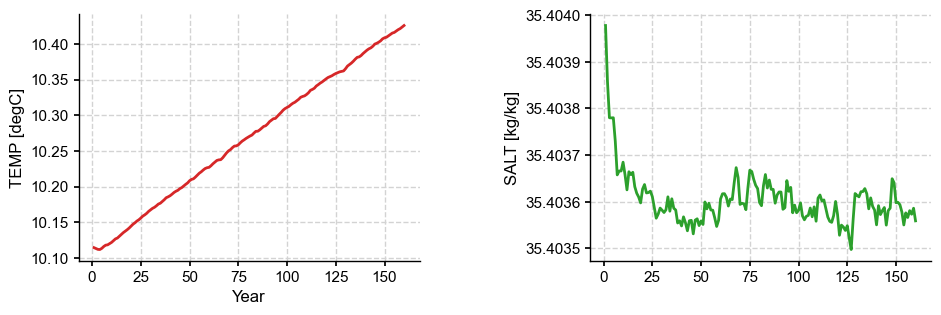

In [5]:
fig, ax = logs.plot_vars(vn=['TEMP', 'SALT'], figsize=(11, 3.2), ncol=2)
x4c.showfig(fig)

## Comparing two runs

`compare_vars` overlays a reference case in black, which is the usual way to check a
branch run against its parent. Here the sample is compared against itself, so the
curves coincide.

>>> Logs.dirpath: ~/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005/logs
>>> 8 Logs.paths:
Start: ocn.log.2682906.desched1.231221-232436.gz
End: ocn.log.2689679.desched1.231224-030444.gz


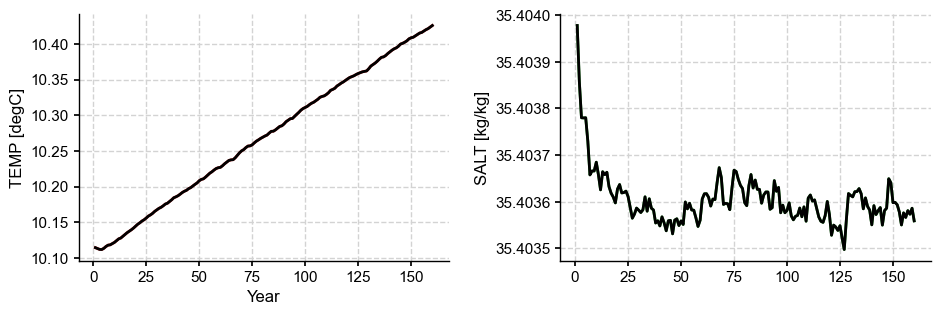

In [6]:
logs_ref = x4c.Logs(log_dir, comp='ocn')
logs_ref.get_vars(vn=['TEMP', 'SALT'])

fig, ax = logs.compare_vars(logs_ref, vn=['TEMP', 'SALT'], figsize=(11, 3.2), ncol=2)
x4c.showfig(fig)

The sample ships only the first eight ocean logs, so the series is short. On a
real case this is the quickest drift check available — no timeseries generation
needed.